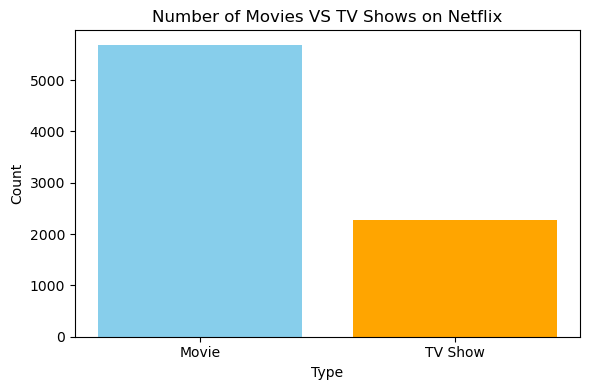

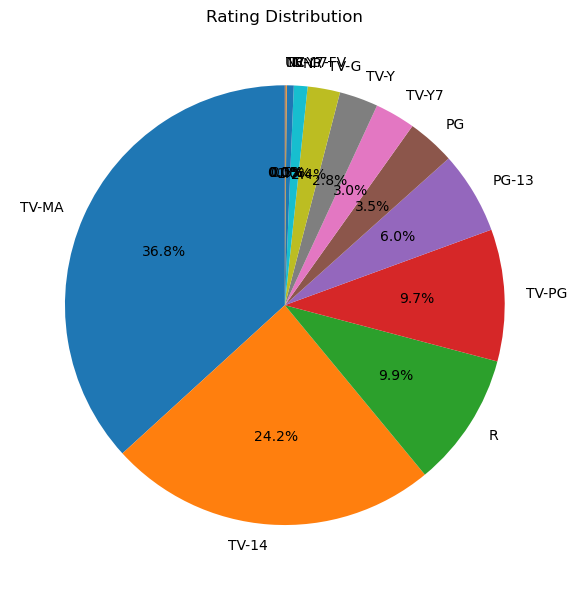

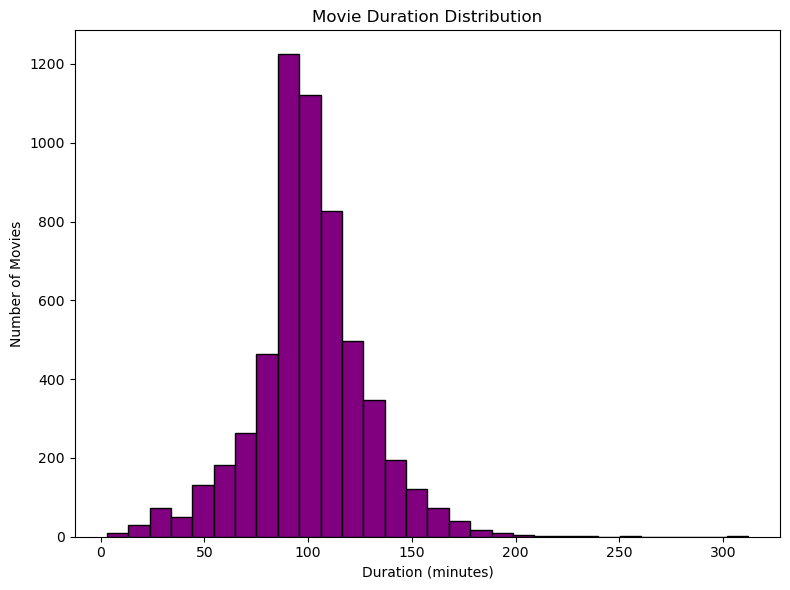

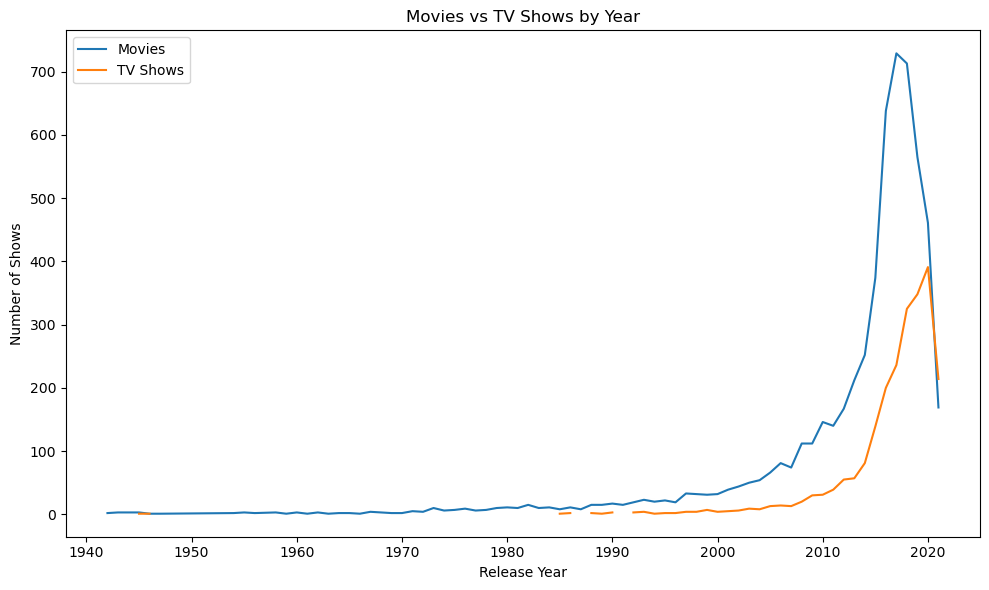

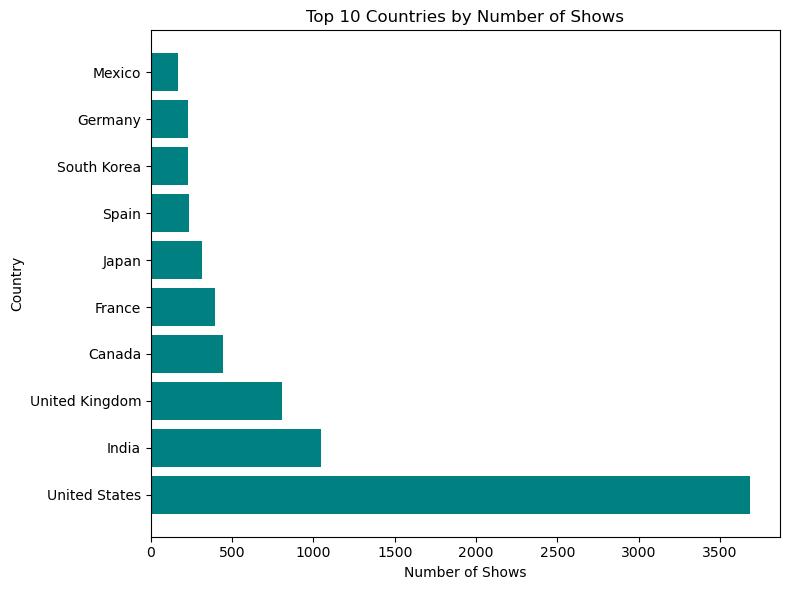

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# load the data
df = pd.read_csv("netflix_titles.csv")

# clean data
df = df.dropna(subset=['type','release_year','rating','country','duration'])

type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'orange'])

plt.title('Number of Movies VS TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('charts/movies_vs_tvshows.png')
plt.show()

rating_counts = df['rating'].value_counts()

plt.figure(figsize=(8,6))
plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Rating Distribution')
plt.tight_layout()
plt.savefig('charts/rating_distribution.png')
plt.show()


movie_df = df[df['type'] == 'Movie'].copy()

movie_df['duration_int'] = movie_df['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins=30, color='purple', edgecolor='black')

plt.title('Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')

plt.tight_layout()
plt.savefig('charts/movie_duration_distribution.png')
plt.show()

year_type_counts = df.groupby(['release_year', 'type']).size().unstack()

plt.figure(figsize=(10,6))

plt.plot(year_type_counts.index, year_type_counts['Movie'], label='Movies')
plt.plot(year_type_counts.index, year_type_counts['TV Show'], label='TV Shows')

plt.title('Movies vs TV Shows by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.legend()

plt.tight_layout()
plt.savefig('charts/movies_vs_tvshows_by_year.png')
plt.show()

country_counts = df['country'].dropna().str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color='teal')

plt.title('Top 10 Countries by Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Country')

plt.tight_layout()
plt.savefig('charts/top_10_countries.png')
plt.show()

content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

plt.figure(figsize=(10,6))

plt.plot(content_by_year.index, content_by_year['Movie'], marker='o', label='Movies')
plt.plot(content_by_year.index, content_by_year['TV Show'], marker='o', label='TV Shows')

plt.title('Movies and TV Shows Released Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.legend()

plt.tight_layout()
plt.savefig('charts/releases_over_the_years.png')
plt.show()
